<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter2/small_angle_tension.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pendulum Tension in the small angle limit


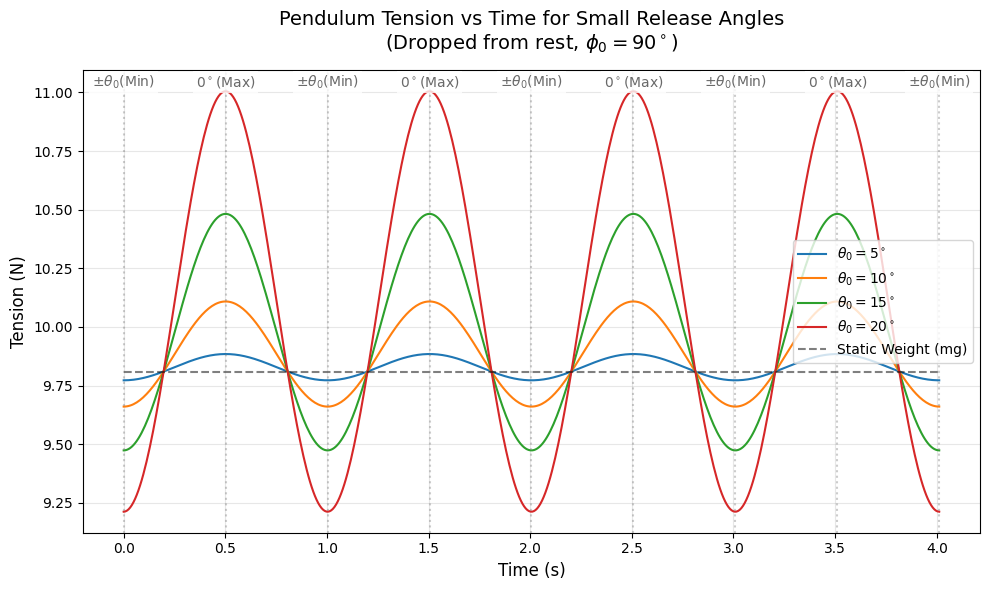

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters for the simulation
m = 1.0      # Mass of the pendulum bob (kg)
g = 9.81     # Acceleration due to gravity (m/s^2)
l = 1.0      # Length of the pendulum string (m)
omega = np.sqrt(g / l)  # Angular frequency (rad/s)

# Initial phase for dropping from rest (90 degrees in radians)
phi_0 = np.pi / 2

# Time array (simulate for exactly 2 full periods)
period = 2 * np.pi / omega
t = np.linspace(0, 2 * period, 500)

# A list of small release angles in degrees to plot
release_angles_deg = [5, 10, 15, 20]

# Initialize the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

for angle_deg in release_angles_deg:
    # Convert angle to radians for the math functions
    theta_0 = np.radians(angle_deg)

    # Calculate the tension over time using the derived small-angle equation:
    # T(t) = mg * [1 + theta_0^2 * (cos^2(wt + phi_0) - 0.5 * sin^2(wt + phi_0))]
    cos_term = np.cos(omega * t + phi_0)**2
    sin_term = np.sin(omega * t + phi_0)**2

    tension = m * g * (1 + (theta_0**2) * (cos_term - 0.5 * sin_term))

    # Plot the curve for this specific angle
    ax1.plot(t, tension, label=fr'$\theta_0 = {angle_deg}^\circ$')

# Add a baseline reference for standard weight (mg) using plot
ax1.plot([t[0], t[-1]], [m * g, m * g], color='black', linestyle='--', alpha=0.5, label='Static Weight (mg)')

# Find the time locations for extrema (every quarter period)
extrema_times = np.arange(0, 2 * period + 0.01, period / 4)

# Force matplotlib to calculate limits so we know where to place text/lines
ax1.autoscale()
y_min, y_max = ax1.get_ylim()

# Add vertical lines and text labels directly to the main axis to avoid mpld3 twiny() bugs
for i, t_val in enumerate(extrema_times):
    # Use standard plot for vertical lines to avoid axvline blended transform warnings
    ax1.plot([t_val, t_val], [y_min, y_max], color='gray', linestyle=':', alpha=0.4)

    # Label them based on whether it's a min or max tension point
    label = fr'$\pm\theta_0$(Min)' if i % 2 == 0 else fr'$0^\circ$(Max)'

    # Place text near the top of the plot
    ax1.text(t_val, y_max - (y_max - y_min) * 0.008, label,
             ha='center', va='top', fontsize=10, color='dimgray',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Reset the y-limits so our drawn vertical lines reach the true top and bottom
ax1.set_ylim(y_min, y_max)

# Add labels and styling for the primary (time) axis
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Tension (N)', fontsize=12)
ax1.legend(loc='center right')
ax1.grid(True, alpha=0.3)

# Add title
plt.title(r'Pendulum Tension vs Time for Small Release Angles' + '\n' + r'(Dropped from rest, $\phi_0 = 90^\circ$)', fontsize=14, pad=15)
plt.tight_layout()

# Display the plot
plt.show()